Top 10 Hashtags OYO - Save
    brand        hashtag_clean  total_like  total_share  total_play  \
243   OYO                  oyo      430360        86858    21378480   
83    OYO                  fyp      422459        81012    19930000   
105   OYO                hotel      404938        73556    17767169   
138   OYO   hotelmurahsurabaya      261800        57718     6400000   
184   OYO          jelajahhepi      193564        25601    14570949   
152   OYO        hotelsurabaya      251303        56955     7787400   
404   OYO           xyzbcafypシ      255400        58293     6400000   
71    OYO  dukuhkupangsurabaya      233900        54200     5200000   
207   OYO          lgresidence      233900        54200     5200000   
283   OYO           penginapan      131045        21244    10693521   

     total_comment  total_save  
243          14645       51481  
83           12991       43496  
105          11602       39685  
138           8143       24592  
184           4826       2

C:\Users\yogib\AppData\Local\Temp\ipykernel_2052\1935862823.py:55: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yogib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


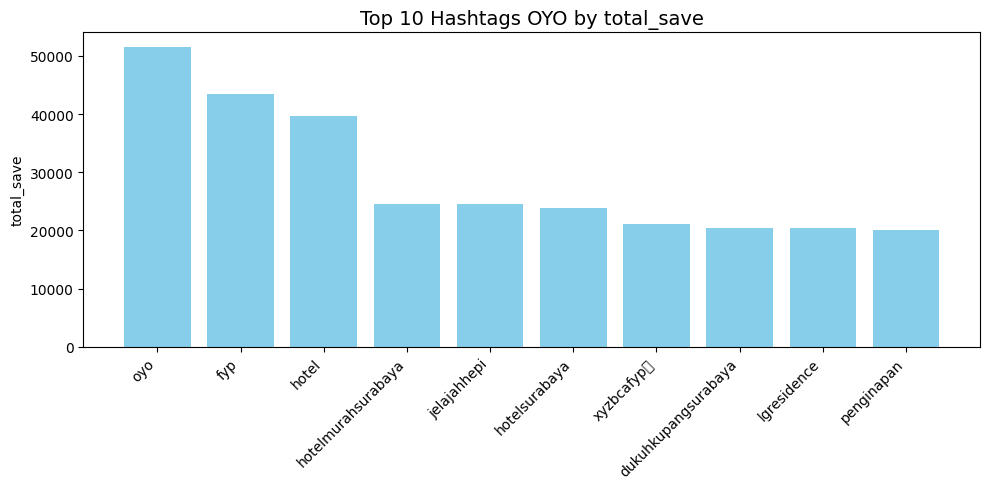

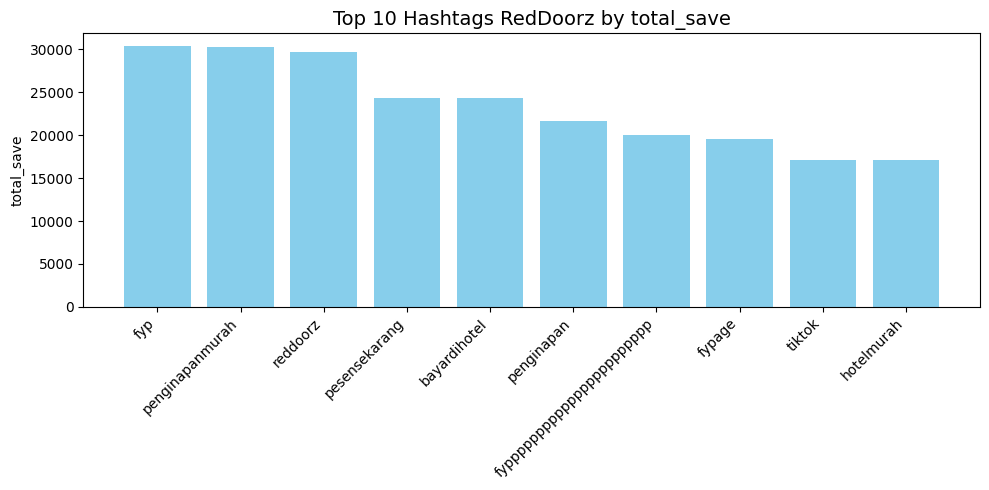

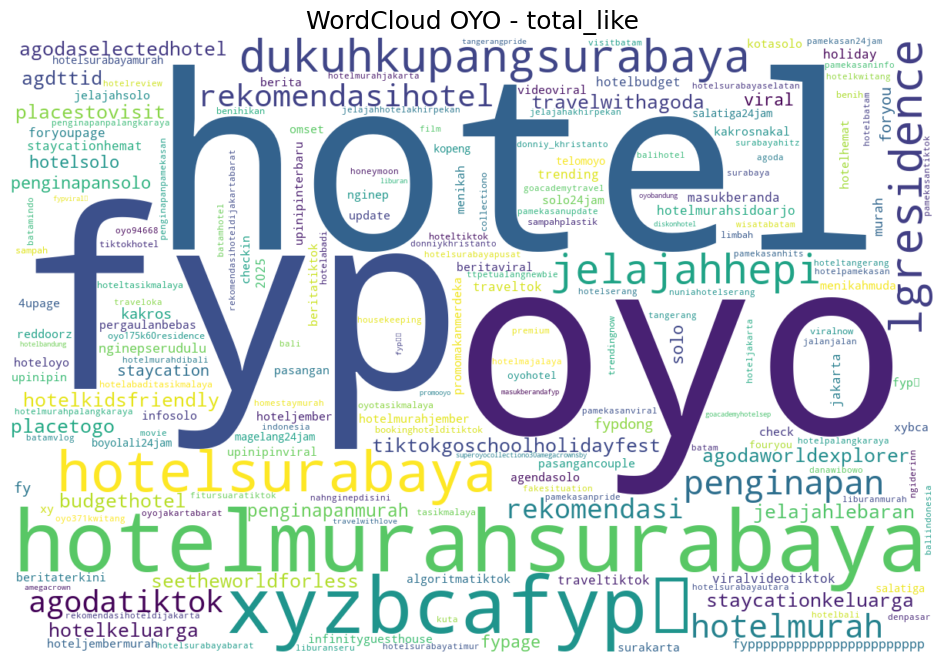

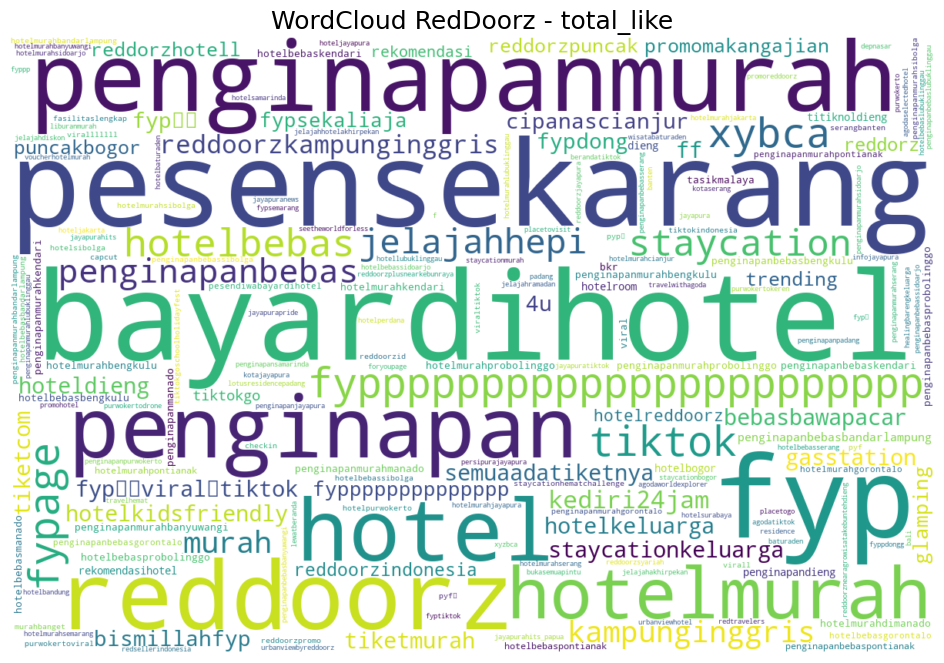

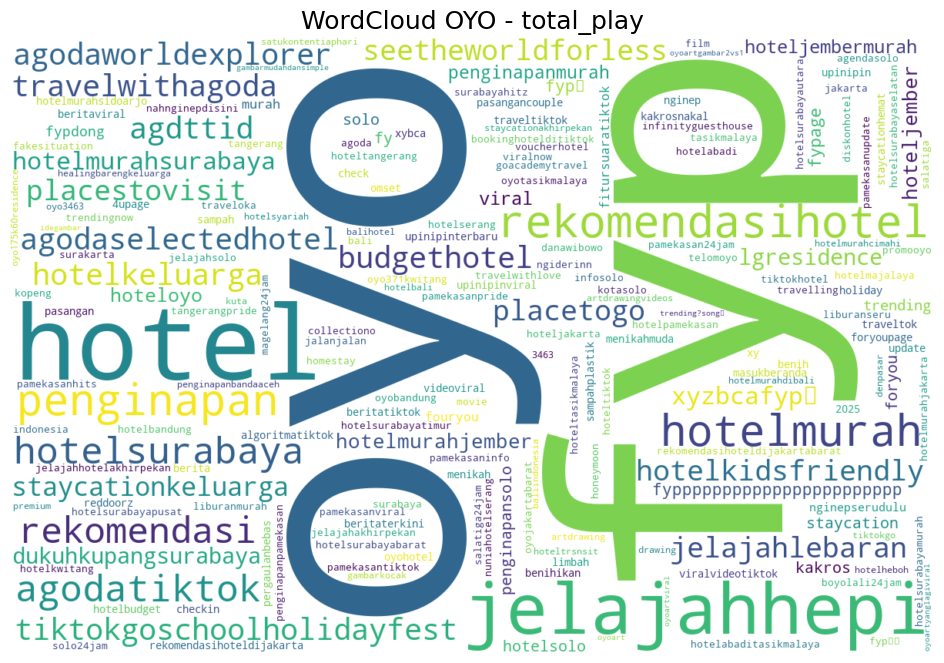

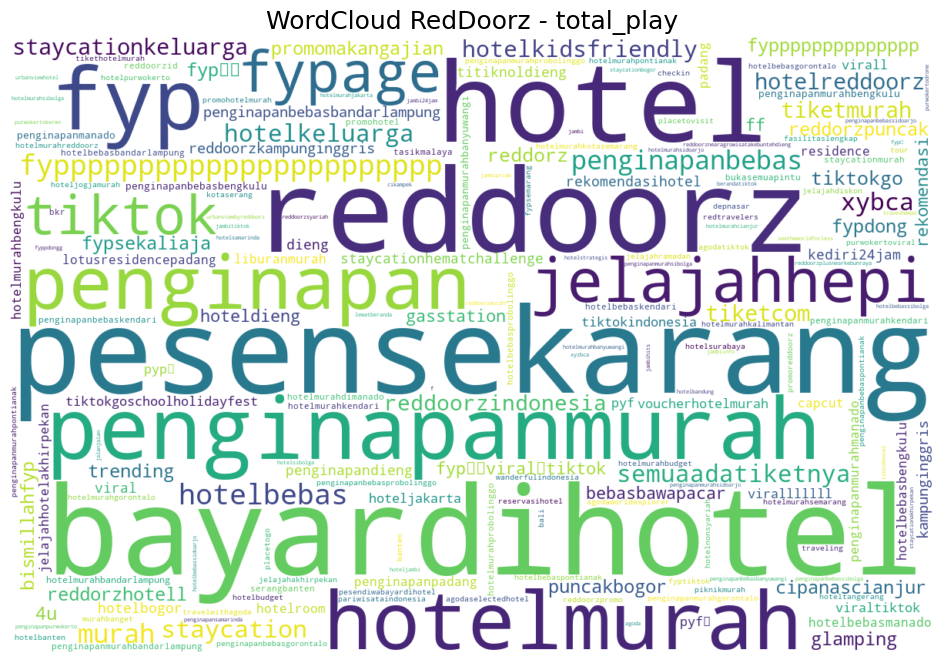

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =========================
# 1. Load Data
# =========================
oyo = pd.read_csv(r"D:\DATA ANALYST-DATA SCIENTIST\MY PROJECT 2025\MARKETING FILE\OYO VS REDDOORZ\Data_clean_oyo.csv", sep=";")
reddoorz = pd.read_csv(r"D:\DATA ANALYST-DATA SCIENTIST\MY PROJECT 2025\MARKETING FILE\OYO VS REDDOORZ\Data_clean_reddoorz.csv", sep=";")

# Tambah kolom brand
oyo["brand"] = "OYO"
reddoorz["brand"] = "RedDoorz"

# Gabung jadi satu dataframe
df = pd.concat([oyo, reddoorz])

# =========================
# 2. Preprocessing Hashtags
# =========================
df["hashtags"] = df["hashtags"].fillna("").astype(str)
df["hashtags_list"] = df["hashtags"].str.split()
df_exploded = df.explode("hashtags_list")

# Bersihkan tanda pagar & lowercase
df_exploded["hashtag_clean"] = df_exploded["hashtags_list"].str.lower().str.replace("#", "", regex=False)

# =========================
# 3. Hitung KPI per Brand & Hashtag
# =========================
hashtag_stats = df_exploded.groupby(["brand", "hashtag_clean"]).agg(
    total_like=("diggCount", "sum"),
    total_share=("shareCount", "sum"),
    total_play=("playCount", "sum"),
    total_comment=("commentCount", "sum"),
    total_save=("collectCount", "sum")
).reset_index()

# =========================
# 4. Fungsi: Top N Hashtag
# =========================
def top_hashtags(df, brand, metric, n=10):
    return df[df["brand"]==brand].sort_values(metric, ascending=False).head(n)

# =========================
# 5. Fungsi: Visualisasi Bar Chart
# =========================
def plot_top_hashtags(df, brand, metric, n=10):
    top = top_hashtags(df, brand, metric, n)
    plt.figure(figsize=(10,5))
    plt.bar(top["hashtag_clean"], top[metric], color="skyblue")
    plt.title(f"Top {n} Hashtags {brand} by {metric}", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# =========================
# 6. Fungsi: WordCloud
# =========================
def make_wordcloud(df, brand, metric):
    data = df[df["brand"]==brand].set_index("hashtag_clean")[metric].to_dict()
    wc = WordCloud(width=1200, height=800, background_color="white").generate_from_frequencies(data)
    plt.figure(figsize=(12,8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud {brand} - {metric}", fontsize=18)
    plt.show()

# =========================
# 7. Contoh Analisis
# =========================
# 🔹 Top 10 hashtags berdasarkan Save (collectCount)
print("Top 10 Hashtags OYO - Save")
print(top_hashtags(hashtag_stats, "OYO", "total_save"))

print("\nTop 10 Hashtags RedDoorz - Save")
print(top_hashtags(hashtag_stats, "RedDoorz", "total_save"))

# 🔹 Visualisasi Bar Chart
plot_top_hashtags(hashtag_stats, "OYO", "total_save")
plot_top_hashtags(hashtag_stats, "RedDoorz", "total_save")

# 🔹 WordCloud Likes & Views
make_wordcloud(hashtag_stats, "OYO", "total_like")
make_wordcloud(hashtag_stats, "RedDoorz", "total_like")

make_wordcloud(hashtag_stats, "OYO", "total_play")
make_wordcloud(hashtag_stats, "RedDoorz", "total_play")